# Prompt Engineering & Fine-Tuning

This notebook demonstrates key prompt engineering techniques and the
concepts behind fine-tuning LLMs. Since we cannot call real LLMs here,
we simulate the patterns and analyze them programmatically.

**Prerequisites:**
```bash
pip install numpy matplotlib pandas
```
📺 **Video Lecture:** [https://youtu.be/_bCEYU-riVU](https://youtu.be/_bCEYU-riVU)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(42)

print('Libraries loaded!')

Libraries loaded!


## 1. Prompt Engineering Patterns

Good prompts follow structured patterns. Let's explore the most effective ones.

In [32]:
# Prompt template patterns
prompt_patterns = {
    'Zero-Shot': {
        'template': 'Classify the sentiment: "{text}"\nSentiment:',
        'example': 'Classify the sentiment: "This product is amazing!"\nSentiment:',
        'when': 'Simple tasks the model already understands',
    },
    'Few-Shot': {
        'template': 'Examples:\n"Great quality" -> Positive\n"Terrible service" -> Negative\n"{text}" ->',
        'example': 'Examples:\n"Great quality" -> Positive\n"Terrible service" -> Negative\n"Decent but pricey" ->',
        'when': 'Tasks needing format guidance or edge cases',
    },
    'Chain-of-Thought': {
        'template': 'Q: {question}\nLet\'s think step by step:\n1.',
        'example': 'Q: If a train travels 60mph for 2.5 hours, how far does it go?\nLet\'s think step by step:\n1.',
        'when': 'Reasoning, math, multi-step logic',
    },
    'Role-Based': {
        'template': 'You are an expert {role}. {task}',
        'example': 'You are an expert data scientist. Explain overfitting to a non-technical stakeholder.',
        'when': 'Specialized knowledge or tone required',
    },
}

for name, info in prompt_patterns.items():
    print(f'=== {name} ===')
    print(f'When to use: {info["when"]}')
    print(f'Example prompt:\n  {info["example"]}')
    print()

=== Zero-Shot ===
When to use: Simple tasks the model already understands
Example prompt:
  Classify the sentiment: "This product is amazing!"
Sentiment:

=== Few-Shot ===
When to use: Tasks needing format guidance or edge cases
Example prompt:
  Examples:
"Great quality" -> Positive
"Terrible service" -> Negative
"Decent but pricey" ->

=== Chain-of-Thought ===
When to use: Reasoning, math, multi-step logic
Example prompt:
  Q: If a train travels 60mph for 2.5 hours, how far does it go?
Let's think step by step:
1.

=== Role-Based ===
When to use: Specialized knowledge or tone required
Example prompt:
  You are an expert data scientist. Explain overfitting to a non-technical stakeholder.



## 2. Prompt Structure Analysis

Let's analyze what makes prompts effective by looking at structure components.

In [33]:
# Anatomy of a well-structured prompt
prompt_components = pd.DataFrame({
    'Component': ['System/Role', 'Context', 'Task/Instruction',
                  'Examples (Few-shot)', 'Output Format', 'Constraints'],
    'Purpose': [
        'Set the persona and expertise level',
        'Provide relevant background information',
        'Clearly state what you want done',
        'Show the desired input-output pattern',
        'Specify JSON, markdown, list, etc.',
        'Length limits, style, what to avoid',
    ],
    'Impact': ['High', 'Medium', 'Critical', 'High', 'High', 'Medium'],
    'Example': [
        'You are a senior ML engineer',
        'Given this dataset with 10K rows...',
        'Classify each review as positive/negative',
        '"Great!" -> Positive',
        'Return as JSON: {"label": ..., "confidence": ...}',
        'Max 100 words, no jargon',
    ],
})
print(prompt_components.to_string(index=False))

          Component                                 Purpose   Impact                                           Example
        System/Role     Set the persona and expertise level     High                      You are a senior ML engineer
            Context Provide relevant background information   Medium               Given this dataset with 10K rows...
   Task/Instruction        Clearly state what you want done Critical         Classify each review as positive/negative
Examples (Few-shot)   Show the desired input-output pattern     High                              "Great!" -> Positive
      Output Format      Specify JSON, markdown, list, etc.     High Return as JSON: {"label": ..., "confidence": ...}
        Constraints     Length limits, style, what to avoid   Medium                          Max 100 words, no jargon


## 3. Temperature and Sampling

Temperature controls randomness in LLM outputs. Let's visualize the effect.

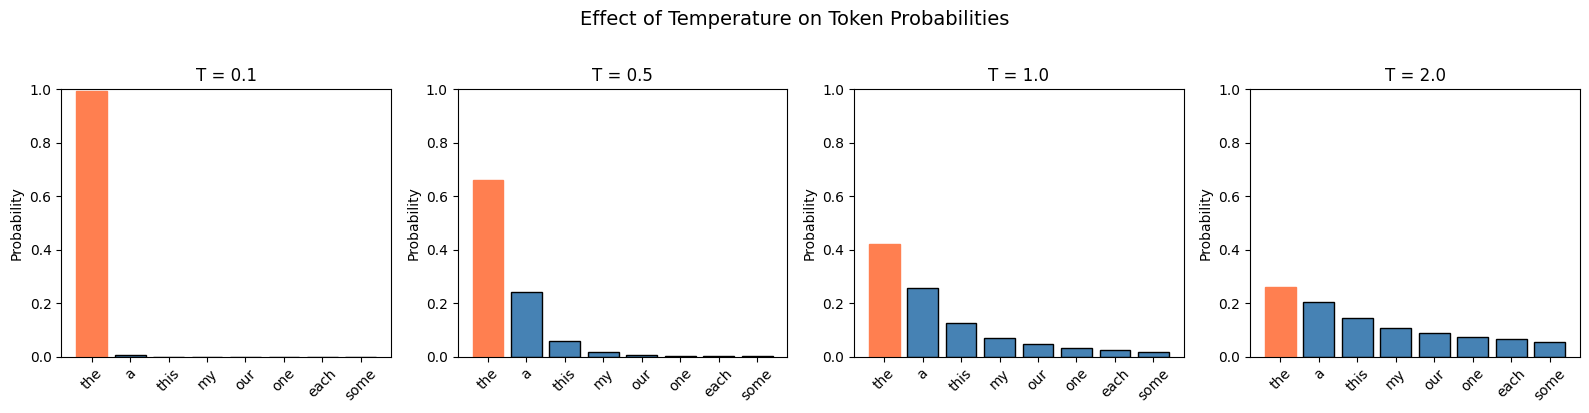

Low T (0.1) = deterministic/focused | High T (2.0) = creative/random


In [34]:
def softmax_with_temperature(logits, temperature=1.0):
    """Apply temperature-scaled softmax."""
    scaled = logits / max(temperature, 1e-8)
    exp_scaled = np.exp(scaled - np.max(scaled))
    return exp_scaled / exp_scaled.sum()

# Simulate token logits for next-word prediction
tokens = ['the', 'a', 'this', 'my', 'our', 'one', 'each', 'some']
logits = np.array([3.0, 2.5, 1.8, 1.2, 0.8, 0.5, 0.2, -0.1])

temperatures = [0.1, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, temp in zip(axes, temperatures):
    probs = softmax_with_temperature(logits, temp)
    bars = ax.bar(tokens, probs, color='steelblue', edgecolor='black')
    bars[0].set_color('coral')  # highlight top token
    ax.set_title(f'T = {temp}', fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Effect of Temperature on Token Probabilities', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print('Low T (0.1) = deterministic/focused | High T (2.0) = creative/random')

## 4. Top-K and Top-P (Nucleus) Sampling

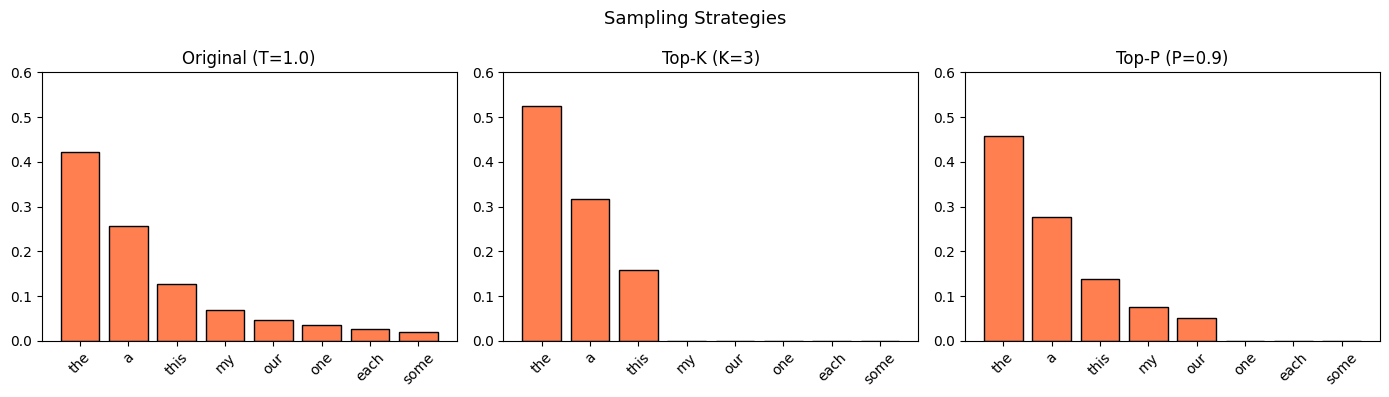

In [35]:
def top_k_sampling(probs, k):
    """Keep only top-k tokens, re-normalize."""
    top_k_idx = np.argsort(probs)[-k:]
    filtered = np.zeros_like(probs)
    filtered[top_k_idx] = probs[top_k_idx]
    return filtered / filtered.sum()

def top_p_sampling(probs, p):
    """Keep smallest set of tokens whose cumulative prob >= p."""
    sorted_idx = np.argsort(probs)[::-1]
    cumsum = np.cumsum(probs[sorted_idx])
    cutoff = np.searchsorted(cumsum, p) + 1
    keep_idx = sorted_idx[:cutoff]
    filtered = np.zeros_like(probs)
    filtered[keep_idx] = probs[keep_idx]
    return filtered / filtered.sum()

base_probs = softmax_with_temperature(logits, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, probs, title in [
    (axes[0], base_probs, 'Original (T=1.0)'),
    (axes[1], top_k_sampling(base_probs, 3), 'Top-K (K=3)'),
    (axes[2], top_p_sampling(base_probs, 0.9), 'Top-P (P=0.9)'),
]:
    colors = ['coral' if p > 0 else 'lightgray' for p in probs]
    ax.bar(tokens, probs, color=colors, edgecolor='black')
    ax.set_title(title); ax.set_ylim(0, 0.6)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Sampling Strategies', fontsize=13)
plt.tight_layout(); plt.show()

## 5. Fine-Tuning Concepts

Fine-tuning adapts a pretrained model to a specific task using task-specific data.

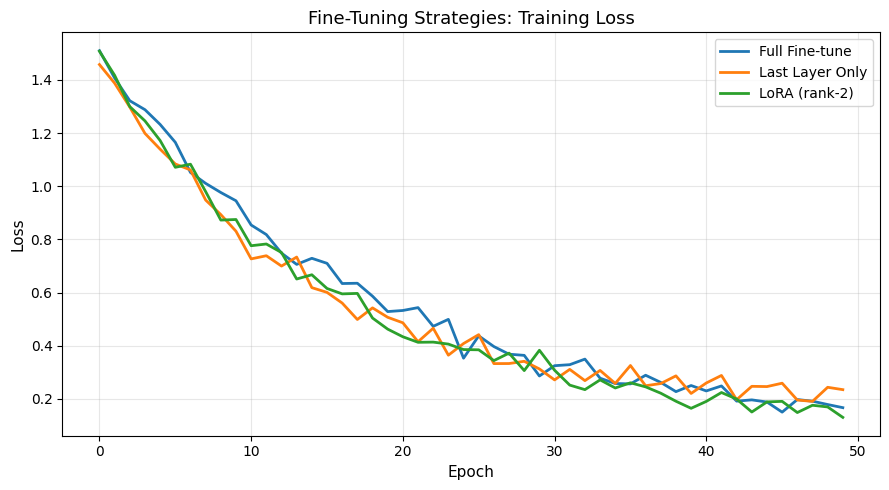

In [36]:
# Simulate fine-tuning: pretrained weights + task adaptation
np.random.seed(42)

# Pretrained model weights (from large general dataset)
W_pretrained = np.random.randn(10, 5) * 0.5

# Task-specific fine-tuning
n_epochs = 50
learning_rates = {'Full Fine-tune': 0.01, 'Last Layer Only': 0.01, 'LoRA (rank-2)': 0.05}
losses = {}

for method, lr in learning_rates.items():
    W = W_pretrained.copy()
    method_losses = []
    
    for epoch in range(n_epochs):
        # Simulate training loss
        if method == 'Full Fine-tune':
            target_loss = 0.1
            rate = 0.06
        elif method == 'Last Layer Only':
            target_loss = 0.2
            rate = 0.08
        else:  # LoRA
            target_loss = 0.12
            rate = 0.07
        
        current_loss = target_loss + (1.5 - target_loss) * np.exp(-rate * epoch)
        current_loss += np.random.randn() * 0.03
        method_losses.append(max(current_loss, target_loss * 0.9))
    
    losses[method] = method_losses

fig, ax = plt.subplots(figsize=(9, 5))
for method, loss_curve in losses.items():
    ax.plot(loss_curve, linewidth=2, label=method)
ax.set_xlabel('Epoch', fontsize=11); ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Fine-Tuning Strategies: Training Loss', fontsize=13)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. LoRA (Low-Rank Adaptation)

Instead of updating all weights, LoRA adds small rank-r matrices.
Dramatically reduces trainable parameters.

Original parameters: 262,144
LoRA parameters (rank=4): 4,096
Parameter reduction: 98.4%

Matrix shapes:
  W: (512, 512) (262,144 params)
  A: (512, 4) (2,048 params)
  B: (4, 512) (2,048 params)


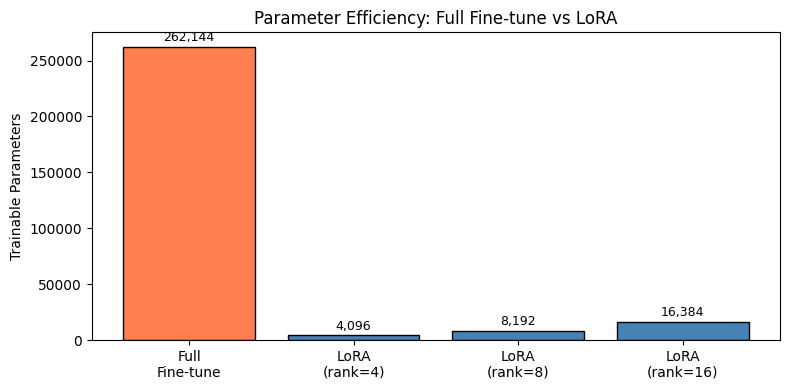

In [37]:
# LoRA concept: W_new = W_pretrained + A @ B (low-rank update)
d_model = 512
rank = 4  # LoRA rank (typically 4-16)

# Original weight matrix
W = np.random.randn(d_model, d_model)

# LoRA matrices (much smaller!)
A = np.random.randn(d_model, rank) * 0.01  # down-project
B = np.random.randn(rank, d_model) * 0.01   # up-project

# Effective weight
W_effective = W + A @ B

original_params = d_model * d_model
lora_params = d_model * rank * 2

print(f'Original parameters: {original_params:,}')
print(f'LoRA parameters (rank={rank}): {lora_params:,}')
print(f'Parameter reduction: {(1 - lora_params/original_params)*100:.1f}%')
print(f'\nMatrix shapes:')
print(f'  W: {W.shape} ({original_params:,} params)')
print(f'  A: {A.shape} ({d_model*rank:,} params)')
print(f'  B: {B.shape} ({rank*d_model:,} params)')

# Visualize parameter efficiency
fig, ax = plt.subplots(figsize=(8, 4))
methods = ['Full\nFine-tune', 'LoRA\n(rank=4)', 'LoRA\n(rank=8)', 'LoRA\n(rank=16)']
params = [original_params, d_model*4*2, d_model*8*2, d_model*16*2]
ax.bar(methods, params, color=['coral', 'steelblue', 'steelblue', 'steelblue'],
       edgecolor='black')
ax.set_ylabel('Trainable Parameters')
ax.set_title('Parameter Efficiency: Full Fine-tune vs LoRA')
for i, v in enumerate(params):
    ax.text(i, v + 5000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

## 7. Evaluation of Prompts & Fine-Tuned Models

      Prompt Strategy  Accuracy      Std
            Zero-Shot     0.714 0.020209
Few-Shot (3 examples)     0.860 0.015518
     Chain-of-Thought     0.882 0.014427


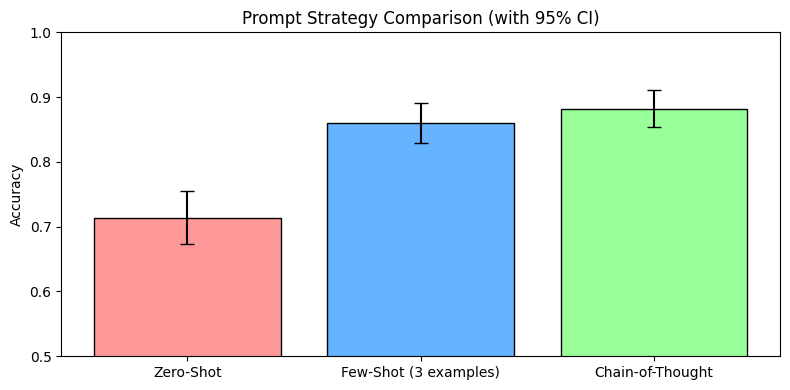

In [38]:
# Simulate A/B testing prompts
np.random.seed(42)
n_tests = 500

# Prompt A: basic zero-shot
accuracy_a = np.random.binomial(1, 0.72, n_tests)
# Prompt B: few-shot with examples
accuracy_b = np.random.binomial(1, 0.85, n_tests)
# Prompt C: chain-of-thought
accuracy_c = np.random.binomial(1, 0.88, n_tests)

results = pd.DataFrame({
    'Prompt Strategy': ['Zero-Shot', 'Few-Shot (3 examples)', 'Chain-of-Thought'],
    'Accuracy': [accuracy_a.mean(), accuracy_b.mean(), accuracy_c.mean()],
    'Std': [accuracy_a.std()/np.sqrt(n_tests), accuracy_b.std()/np.sqrt(n_tests),
            accuracy_c.std()/np.sqrt(n_tests)],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(results['Prompt Strategy'], results['Accuracy'],
       yerr=results['Std']*2, color=['#ff9999', '#66b3ff', '#99ff99'],
       edgecolor='black', capsize=5)
ax.set_ylabel('Accuracy'); ax.set_ylim(0.5, 1.0)
ax.set_title('Prompt Strategy Comparison (with 95% CI)')
plt.tight_layout(); plt.show()

## 8. Interview Takeaways

**Prompt Engineering:**
- Zero-shot for simple tasks; few-shot for format guidance; CoT for reasoning
- Structure: role + context + task + format + constraints
- Temperature: low (0.0-0.3) for factual, high (0.7-1.0) for creative
- Top-K and Top-P control sampling diversity

**Fine-Tuning:**
- Full fine-tuning updates all weights (most flexible, most expensive)
- **LoRA** adds low-rank matrices — reduces trainable params by 90%+
- **QLoRA** = quantized base model + LoRA (fits on consumer GPUs)
- Always evaluate: accuracy, latency, cost, and alignment
- Prompt engineering is often sufficient before resorting to fine-tuning

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>